<a href="https://colab.research.google.com/github/HimanshiShri/Himashri-Projects/blob/main/Neural%20Network%20in%20Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Apple Inc. Stock (AAPL)
We'll use 10 years of Apple stock data (2015-2025) to train our model to predict whether the stock price will go UP or DOWN tomorrow.

Our Goal: Build a model that can predict stock direction with reasonable accuracy using Keras.

# Step 1: Import Libraries and Download Data

In [2]:
pip install scikit-learn

In [3]:
# Install yfinance API for Apple Inc company
!pip install yfinance
!pip install matplotlib
!pip install tensorflow


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download historical stock data
data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')

# Display basic info
print(data.tail())

/tmp/ipykernel_3418/2800607168.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-24  256.339722  256.349629  253.450669  253.649240  23234700
2024-12-26  257.153809  258.226044  255.773839  256.329802  27237100
2024-12-27  253.748535  256.836144  251.236764  255.972387  42355300
2024-12-30  250.382965  251.673602  248.943415  250.412748  35557500
2024-12-31  248.615784  251.455179  247.632911  250.621234  39480700


In [5]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

# Step 2: Feature Engineering and Target Variable

In [6]:
# Create technical indicators
data['Return'] = data['Close'].pct_change()
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data['Volatility'] = data['Return'].rolling(window=10).std()

# Drop missing values
data.dropna(inplace=True)

# Create binary target: 1 if next day is up, 0 otherwise
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

print(data[['Return', 'MA10', 'MA50', 'Volatility', 'Target']].tail())

Price         Return        MA10        MA50 Volatility Target
Ticker                                                        
Date                                                          
2024-12-24  0.011478  249.479526  234.123974   0.011168      1
2024-12-26  0.003176  250.723495  234.628849   0.010694      0
2024-12-27 -0.013242  251.480997  235.106676   0.012133      0
2024-12-30 -0.013263  251.885063  235.509853   0.013197      0
2024-12-31 -0.007058  251.823509  235.821159   0.012947      0


1. pct_change() — Calculating Returnspct_change() calculates the percentage change between the current row's value and a previous row's value (by default, the immediate previous day).In finance, we rarely feed raw stock prices (like $150, $152, $148) directly into a machine learning model. Instead, we use pct_change() to calculate Daily Returns, which standardizes the data and tells us if the stock is gaining or losing momentum.🔢 Financial Example:Imagine Apple's closing prices over three days:Day 1: $100Day 2: $105Day 3: $99.75When you apply .pct_change(), Python does the math: (New Price - Old Price) / Old PriceDay 1: NaN (Not a Number, because there is no Day 0 to compare it to)Day 2: (105 - 100) / 100 = 0.05 (a +5% return)Day 3: (99.75 - 105) / 105 = -0.05 (a -5% return)🔄

2. rolling() — Moving Window Calculationsrolling() creates a moving window over your data. It allows you to look backward at a specific number of past days (e.g., 10 days or 50 days) and calculate a single metric over that specific time frame.As time moves forward, the window "rolls" forward too, always capturing the most recent chunk of days and dropping the oldest. It is primarily used to smooth out daily market noise and highlight broader trends.🔢 Financial Example:If you want to calculate a 10-day Moving Average (MA10), you write .rolling(window=10).mean().On Day 10: It takes the prices from Day 1 through Day 10, calculates their average, and outputs it.On Day 11: The window shifts. It drops Day 1, takes the prices from Day 2 through Day 11, and calculates their average.On Day 12: It drops Day 2, averages Day 3 through Day 12, and so on.🛠️ Combining it with other metrics:In your code, rolling() is used twice:.rolling(window=10).mean(): Groups the last 10 days to find the average trend..rolling(window=10).std(): Groups the last 10 days to find the standard deviation (Volatility), showing how wildly prices are swinging in that 10-day block.

# Step 3: Preparing Data for Neural Networks

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = ['Return', 'MA10', 'MA50', 'Volatility']
X = data[features]
y = data['Target']

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# Step 4: Building a Neural Network with Keras

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Define the model using an explicit Input layer
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary output
])

#model.summary()

# # Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)


Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5014 - loss: 0.6976 - val_accuracy: 0.5000 - val_loss: 0.6988
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5183 - loss: 0.6947 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.4798 - val_loss: 0.6957
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5262 - loss: 0.6907 - val_accuracy: 0.5051 - val_loss: 0.6935
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5268 - loss: 0.6905 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5121 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5330 - loss: 0.6897 - val_accuracy: 0.5253 - val_loss: 0.6939
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5346 - loss: 0.6896 - val_accuracy: 0.5000 - val

In [15]:
model.summary()
Input(shape=(X_train.shape[1],)),
Dense(128, activation='relu'),
Dropout(0.3),
Dense(64, activation='relu'),
Dense(1, activation='sigmoid')  # Binary output

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,885 (105.02 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,924 (70.02 KB)

<Dense name=dense_5, built=False>

# Step 5: Model Evaluation

In [16]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# Predict on test set
predictions = (model.predict(X_test) > 0.5).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5061 - loss: 0.7068 
Test Accuracy: 0.51
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[139  79]
 [165 111]]
              precision    recall  f1-score   support

           0       0.46      0.64      0.53       218
           1       0.58      0.40      0.48       276

    accuracy                           0.51       494
   macro avg       0.52      0.52      0.50       494
weighted avg       0.53      0.51      0.50       494



# Step 6: Visualizing Model Performance

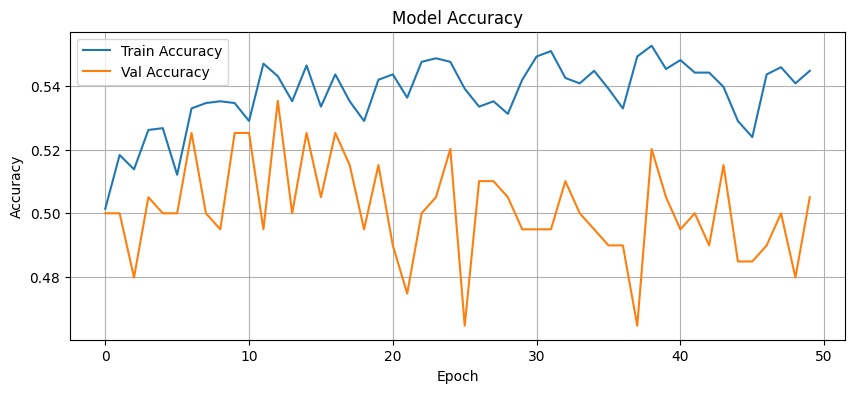

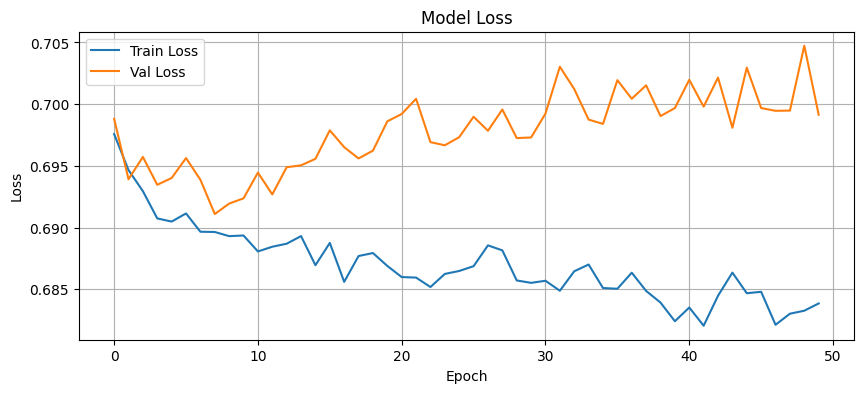

In [17]:
# Plot accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Strategies to Increase Model Accuracy

Improving a machine learning model, especially for complex tasks like stock prediction, is an iterative process. When our model's accuracy is around 50%, it tells us we need to go back and refine our approach significantly. Here are some key strategies you can explain:

### Strategy 1: Enhanced Feature Engineering (Giving the model more relevant clues)

Our current features (`Return`, `MA10`, `MA50`, `Volatility`) are a good start, but financial markets are influenced by many factors. We need to provide the model with richer information.

*   **Lagged Features**: Stock prices are sequential. What happened yesterday often influences what happens today. By adding 'lagged' versions of our existing features (e.g., yesterday's `Return`, yesterday's `MA10`), we give the model historical context. It's like asking: "What was the trend yesterday, and the day before, in addition to today?"

*   **More Technical Indicators**: There are hundreds of technical indicators used by traders. Including more can provide diverse perspectives on market sentiment, momentum, and overbought/oversold conditions. Examples include:
    *   **Relative Strength Index (RSI)**: Measures the speed and change of price movements.
    *   **Moving Average Convergence Divergence (MACD)**: Reveals trend strength and direction.
    *   **Bollinger Bands**: Measure market volatility and can indicate potential reversals.

*   **Volume-based Features**: Trading volume often precedes price movements. High volume on a price increase might signal strong conviction, while low volume might signal hesitation. Features related to volume can be very informative.

*   **External Data**: For a real-world scenario, you might even consider incorporating sentiment from news articles, social media, or broader economic indicators (e.g., interest rates, GDP growth).

In [18]:
import numpy as np

# --- Enhanced Feature Engineering ---
# 1. Add Lagged Features
# We'll create lagged versions of our existing features for 1, 2, and 3 days prior
lag_features = ['Return', 'MA10', 'MA50', 'Volatility']
for feature in lag_features:
    for lag in range(1, 4): # Lag for 1, 2, and 3 days
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# Add a couple more basic technical indicators (for demonstration)
# 2. Relative Strength Index (RSI)
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = calculate_rsi(data, window=14)

# 3. Moving Average Convergence Divergence (MACD)
data['EMA12'] = data['Close'].ewm(span=12, adjust=False).mean()
data['EMA26'] = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = data['EMA12'] - data['EMA26']
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()


# Drop any new NaN values created by lags and new indicators
data.dropna(inplace=True)

# Redefine features to include the new ones
new_features = ['Return', 'MA10', 'MA50', 'Volatility', 'RSI', 'MACD', 'Signal_Line']
# Add all lagged features to the list as well
for feature in lag_features:
    for lag in range(1, 4):
        new_features.append(f'{feature}_lag{lag}')

X_new = data[new_features]
y_new = data['Target']

# Display the new features and target
print(X_new.head())
print(y_new.head())


Price         Return       MA10       MA50 Volatility        RSI      MACD  \
Ticker                                                                       
Date                                                                         
2015-04-02  0.008612  27.768388  27.517067   0.014920  50.342197 -0.024145   
2015-04-06  0.016198  27.800572  27.585395   0.015345  57.650246  0.016932   
2015-04-07 -0.010522  27.773936  27.645210   0.015385  52.190190  0.025195   
2015-04-08 -0.003253  27.749743  27.702674   0.015367  50.610893  0.024123   
2015-04-09  0.007643  27.820328  27.781911   0.012642  54.112697  0.040007   

Price      Signal_Line Return_lag1 Return_lag2 Return_lag3  MA10_lag1  \
Ticker                                                                  
Date                                                                    
2015-04-02    0.008409   -0.001447   -0.015352    0.025315  27.816776   
2015-04-06    0.010113    0.008612   -0.001447   -0.015352  27.768388   
2015-04-07

### Strategy 2: Different Model Architecture (Using a model better suited for sequences)

Our current simple neural network (a 'feed-forward' network) treats each day's data independently, even though we introduced lagged features. For time series data, where the order and history of data points are crucial, a different type of neural network is often more effective.

*   **Recurrent Neural Networks (RNNs) / Long Short-Term Memory (LSTM) Networks**: Explain these as neural networks specifically designed to remember sequences. Imagine a human remembering past events to make a current decision; LSTMs do something similar. They have 'memory cells' that allow them to carry information from previous time steps forward, making them powerful for predictions where context over time is important. This is particularly relevant for stock prices where patterns unfold over periods.

    We'll demonstrate a basic LSTM model. To use LSTMs, our input data needs to be reshaped into a 3D format: `[samples, time steps, features]`.

Original X_train_new shape: (1963, 19)
Reshaped X_train_lstm shape for LSTM: (1963, 1, 19)

LSTM Model Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        48,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,101 (207.43 KB)

 Trainable params: 53,101 (207.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5170 - loss: 0.6956 - val_accuracy: 0.4772 - val_loss: 0.6956
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5068 - loss: 0.6913 - val_accuracy: 0.4721 - val_loss: 0.6963
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5317 - loss: 0.6885 - val_accuracy: 0.4924 - val_loss: 0.6979
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5283 - loss: 0.6891 - val_accuracy: 0.4772 - val_loss: 0.7007
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5357 - loss: 0.6857 - val_accuracy: 0.5127 - val_loss: 0.6979
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5323 - loss: 0.6878 - val_accuracy: 0.5381 - val_loss: 0.6997
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5481 - loss: 0.6851 - val_accuracy: 0.5178 - val_loss: 0.6994
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5402 - loss: 0.6833 - val_accuracy: 0.5178 - val_loss

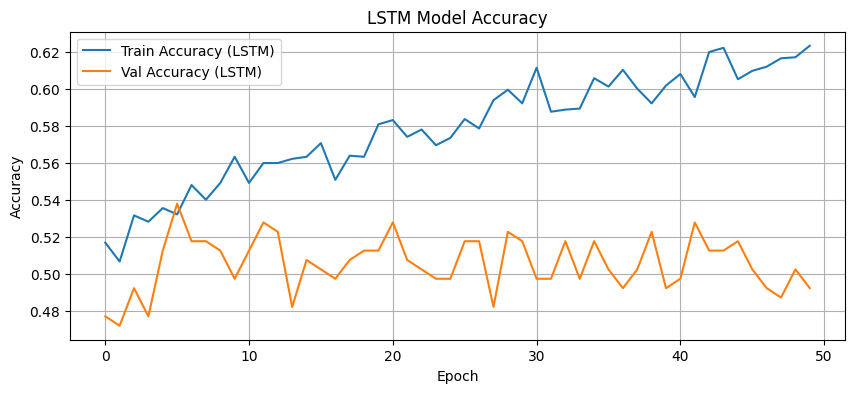

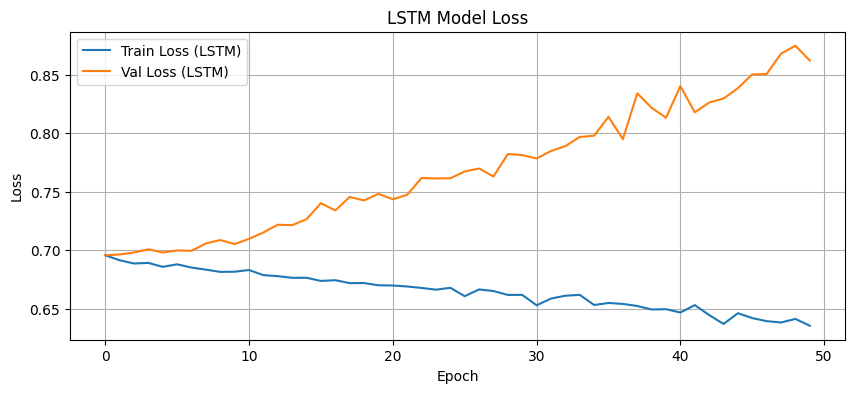

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# --- Data Preparation for LSTM ---
# Re-scale the new features
scaler_new = StandardScaler()
X_scaled_new = scaler_new.fit_transform(X_new)

# Split into training and test datasets (maintaining time order)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_scaled_new, y_new, test_size=0.2, shuffle=False)

# LSTMs expect 3D input: (samples, timesteps, features)
# For simplicity, let's treat each day as a single timestep for now (timesteps=1)
# If we wanted to look at sequences of past days for one prediction, timesteps would be > 1
X_train_lstm = X_train_new.reshape(X_train_new.shape[0], 1, X_train_new.shape[1])
X_test_lstm = X_test_new.reshape(X_test_new.shape[0], 1, X_test_new.shape[1])

print(f"Original X_train_new shape: {X_train_new.shape}")
print(f"Reshaped X_train_lstm shape for LSTM: {X_train_lstm.shape}")

# --- Building an LSTM Model ---
model_lstm = Sequential([
    LSTM(100, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid') # Binary output
])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

print("\nLSTM Model Summary:")
model_lstm.summary()

# Train the LSTM model
history_lstm = model_lstm.fit(X_train_lstm, y_train_new, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Evaluate the LSTM model
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test_lstm, y_test_new)
print(f"\nLSTM Test Accuracy: {accuracy_lstm:.2f}")

# Plot accuracy for LSTM
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy (LSTM)')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy (LSTM)')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss for LSTM
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss (LSTM)')
plt.plot(history_lstm.history['val_loss'], label='Val Loss (LSTM)')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Strategy 3: Hyperparameter Tuning (Fine-tuning the model's 'learning style')

Just like different students learn best with different study techniques, neural networks perform best with specific configurations of their internal settings (hyperparameters). We can systematically experiment with these:

*   **Learning Rate**: How big are the steps the optimizer takes? Too big, and it might overshoot the best solution; too small, and it takes too long to learn.
*   **Number of Layers/Neurons**: How complex should the network be? More layers and neurons can learn more complex patterns but risk overfitting.
*   **Dropout Rate**: How much 'forgetting' helps prevent overfitting?
*   **Epochs and Batch Size**: How many times does the model see the data, and in what sized chunks?

This is often done using techniques like Grid Search or Random Search, but for a BBA lecture, the key takeaway is that these settings are not arbitrary and significantly impact performance.

### Strategy 4: Robust Validation Strategy (More rigorous testing)

For time series data, simply splitting data randomly can lead to 'data leakage' (where the model indirectly sees future information). A more robust approach is:

*   **Walk-Forward Validation**: This mimics how a trader operates. The model is trained on data up to a certain point, then predicts the *next* period. Then, the training window slides forward to include that predicted period, and the process repeats. This ensures the model is always predicting on truly unseen future data.

## Summary

When faced with a model that performs poorly, the answer isn't usually one magic fix. It's a combination of:

1.  **Providing more intelligent and diverse inputs (Feature Engineering).**
2.  **Using a model architecture that is inherently better suited for the type of data (e.g., LSTMs for sequential data).**
3.  **Carefully tuning the model's internal learning parameters (Hyperparameter Tuning).**
4.  **Ensuring our testing method accurately reflects real-world performance (Robust Validation).**

Even with these improvements, predicting stock prices remains incredibly challenging due to the market's inherent randomness and efficiency. The goal is often to find small, consistent edges rather than perfect predictions. This entire process demonstrates the scientific and iterative nature of data science in business.